In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import statsmodels.api as sm
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
 
from sklearn.preprocessing import RobustScaler


In [3]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [4]:
# Need to choose patient_id from OUS_D3 in response_OUS
data = list(OUS_D3['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 

# Merge OUS_D3 with response_OUS
clinical_train = pd.merge(OUS_D3, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS', 'LRC', 'event_LRC'])]

In [5]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [6]:
# Check null values in D3
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [7]:
(MAASTRO_D3['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [8]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [9]:
# need to choose patient_id from MAASTRO_D3 in response_MAASTRO
data = list(MAASTRO_D3['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [10]:
# Merge MAASTRO_D3 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D3, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'DFS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,OS,OS_event
0,1,55,0,0,1,0,0,1,1,1,...,0.028808,0.837387,0.000026,0.001705,0.122209,0.000026,0.008291,0.000341,62.43,0.0
1,2,55,0,0,1,0,0,0,0,0,...,0.049615,0.806842,0.000167,0.002958,0.128976,0.000167,0.008148,0.000335,60.00,0.0
2,3,55,0,0,1,0,0,0,0,1,...,0.019514,0.830272,0.000057,0.001831,0.137282,0.000000,0.008641,0.000229,44.43,1.0
3,4,61,1,0,0,0,1,1,0,1,...,0.047155,0.760949,0.000000,0.003597,0.171595,0.000080,0.013187,0.000240,37.20,1.0
4,6,70,0,0,1,0,0,1,1,1,...,0.033990,0.824865,0.000000,0.002116,0.128134,0.000035,0.009379,0.000529,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,66,1,0,0,0,1,0,0,0,...,0.017489,0.834590,0.000000,0.001321,0.137194,0.000078,0.008706,0.000078,19.00,1.0
95,111,63,0,0,0,0,1,0,0,1,...,0.029979,0.821431,0.000000,0.000543,0.137620,0.000054,0.008907,0.000489,85.87,1.0
96,112,63,0,0,1,0,0,1,1,1,...,0.017354,0.859957,0.000000,0.000988,0.115099,0.000028,0.005700,0.000141,42.87,0.0
97,113,54,0,0,1,0,0,1,1,0,...,0.025399,0.847908,0.000000,0.001487,0.117654,0.000000,0.005759,0.000038,58.93,0.0


In [11]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [12]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,OS,OS_event


In [13]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS'])]

# y 
y = clinical_train.loc[:, ['OS', 'event_OS']]

In [14]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [15]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 388)
y_train:  (139,)


In [16]:
clinical_test.rename(columns = {'OS_event' : 'event_OS'}, inplace = True)

In [17]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'event_OS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['OS', 'event_OS']]
lower, upper = np.percentile(y_MAASTRO['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_OS'], y_MAASTRO['OS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 390)

# Standardization for Clustering

In [18]:
original_X = X.copy()

In [19]:
# Standardize the data 
## Save the column and index 
X_columns = X.columns 
X_index = X.index

## Standardize the data but not the categorical columns
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

### Separate the categorical and non-categorical columns
X_categorical = X[categorical_columns]
X_numeric = X.drop(categorical_columns, axis=1)
X_numeric_columns = X_numeric.columns
X_numeric_index = X_numeric.index

### Standardize non-categorical and then concat with the categorical
scaler = RobustScaler()  
X_numeric_std = scaler.fit_transform(X_numeric)
X_numeric_std = pd.DataFrame(X_numeric_std, columns=X_numeric_columns, index=X_numeric_index)
X_std = pd.concat([X_categorical, X_numeric_std], axis=1)

## Sort the order of the columns as it was in the clinical train 
X_std = X_std[original_X.columns]

## Feature Selection

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

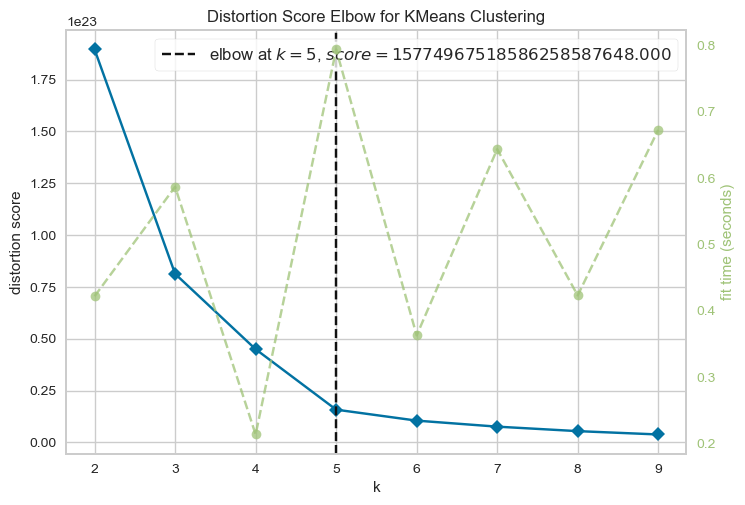

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [20]:
# How many clusters to form - 1. Using elbow method 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

In [21]:
num_clusters = 5  
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(5):
    variance = X_std[X_std.columns[cluster_labels==i]].var()

    # Find the most correlated column
    high_variance_column = variance.abs().idxmax()

    # Get the correlation coefficient of the most correlated column
    max_variance = variance.abs().max()

    print(i)
    print("Most correlated column:", high_variance_column)
    print("Correlation coefficient:", max_variance)
    print('\n')
    selected_features.append(high_variance_column)

KMeans(n_clusters=5)

0
Most correlated column: gldm_LargeDependenceLowGrayLevelEmphasis_d_1_CT_b20
Correlation coefficient: 46.818339041452326


1
Most correlated column: glcm_ClusterShade_d_1_CT_b20
Correlation coefficient: 34.76129123954451


2
Most correlated column: glszm_LargeAreaLowGrayLevelEmphasis_PET_c04
Correlation coefficient: 5087.237820106097


3
Most correlated column: glszm_LargeAreaLowGrayLevelEmphasis_PET_b2
Correlation coefficient: 1055.19167151558


4
Most correlated column: glszm_LargeAreaLowGrayLevelEmphasis_CT_c16
Correlation coefficient: 70.1247383577268




In [22]:
# Selecting features in the DataFrame
X_fs_hv = X[selected_features]
X_new = X_fs_hv.copy()

X_MAASTRO_fs_hv = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_fs_hv.copy()

# Standardization

In [23]:
# Standardize X_new, the new data with the selected features only 
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
scaler = RobustScaler() 
X_new_numeric_columns = X_new_numeric.columns
X_new_numeric_index = X_new_numeric.index 
X_new_numeric_std = scaler.fit_transform(X_new_numeric)
X_new_numeric_std = pd.DataFrame(X_new_numeric_std,
                                 columns=X_new_numeric_columns, 
                                 index=X_new_numeric_index)
X_new_std = pd.concat([X_new_numeric_std, X_new_categoric], axis=1)

# Change the order of the X_new_std 
X_new_std = X_new_std[X_new.columns]

In [24]:
# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = scaler.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
MAASTRO_new_std = MAASTRO_new_std[MAASTRO_new.columns]

In [25]:
X_new

,gldm_LargeDependenceLowGrayLevelEmphasis_d_1_CT_b20,glcm_ClusterShade_d_1_CT_b20,glszm_LargeAreaLowGrayLevelEmphasis_PET_c04,glszm_LargeAreaLowGrayLevelEmphasis_PET_b2,glszm_LargeAreaLowGrayLevelEmphasis_CT_c16
0,0.056560,-298.895100,879096.343994,2.625216e+05,7442.066260
1,0.095346,-535.365447,26566.901706,1.242203e+05,238.870676
2,0.052264,-1376.524977,647295.586841,2.397332e+06,12957.157420
3,0.027762,-847.392287,40145.962374,1.252457e+06,233.632355
4,0.034148,-1188.023474,10927.978256,1.366458e+05,121.921768
...,...,...,...,...,...
134,0.176183,8.640931,215024.891557,4.128076e+05,1528.464999
135,0.148848,-686.754900,338158.975184,3.892908e+06,41182.958565
136,0.130961,-948.768231,974304.249507,1.734434e+05,3964.057173
137,0.258550,-90.384402,199030.525466,1.164868e+06,5243.112516


In [26]:
X_new_std

,gldm_LargeDependenceLowGrayLevelEmphasis_d_1_CT_b20,glcm_ClusterShade_d_1_CT_b20,glszm_LargeAreaLowGrayLevelEmphasis_PET_c04,glszm_LargeAreaLowGrayLevelEmphasis_PET_b2,glszm_LargeAreaLowGrayLevelEmphasis_CT_c16
0,-0.473236,0.296721,0.627985,-0.165378,0.233483
1,-0.033964,0.122953,-0.249270,-0.309221,-0.164858
2,-0.521881,-0.495167,0.389462,2.054971,0.538471
3,-0.799374,-0.106338,-0.235297,0.864223,-0.165148
4,-0.727051,-0.356648,-0.265362,-0.296297,-0.171326
...,...,...,...,...,...
134,0.881543,0.522711,-0.055346,-0.009070,-0.093543
135,0.571968,0.011705,0.071360,3.610473,2.099375
136,0.369390,-0.180833,0.725955,-0.258025,0.041147
137,1.814381,0.449943,-0.071804,0.773124,0.111879


In [27]:
MAASTRO_new

,gldm_LargeDependenceLowGrayLevelEmphasis_d_1_CT_b20,glcm_ClusterShade_d_1_CT_b20,glszm_LargeAreaLowGrayLevelEmphasis_PET_c04,glszm_LargeAreaLowGrayLevelEmphasis_PET_b2,glszm_LargeAreaLowGrayLevelEmphasis_CT_c16
0,0.203608,-334.546058,1.125054e+06,3.686456e+05,9404.025346
1,0.077923,-6216.225223,1.948450e+06,2.114589e+06,16468.863361
2,0.119332,-1732.064419,1.403912e+06,4.579214e+05,3829.811759
3,1.487269,-21920.694268,4.555744e+05,9.121242e+05,2212.056593
4,0.129126,-235.807498,8.660429e+05,3.260921e+06,20185.616389
...,...,...,...,...,...
94,0.097901,319.664572,9.500595e+05,5.034748e+04,18006.593217
95,0.135426,-19066.639918,3.718008e+06,8.736992e+05,1303.136099
96,0.083343,-997.961427,2.726200e+06,7.999319e+06,8928.353080
97,0.071296,-37.054161,2.138315e+06,6.943470e+05,13835.684015


In [28]:
MAASTRO_new_std

,gldm_LargeDependenceLowGrayLevelEmphasis_d_1_CT_b20,glcm_ClusterShade_d_1_CT_b20,glszm_LargeAreaLowGrayLevelEmphasis_PET_c04,glszm_LargeAreaLowGrayLevelEmphasis_PET_b2,glszm_LargeAreaLowGrayLevelEmphasis_CT_c16
0,1.192147,0.270523,0.881077,-0.055002,0.341981
1,-0.231290,-4.051583,1.728353,1.760899,0.732670
2,0.237686,-0.756432,1.168022,0.037851,0.033723
3,15.730108,-15.591890,0.192180,0.510253,-0.055740
4,0.348610,0.343080,0.614553,2.953163,0.938209
...,...,...,...,...,...
94,-0.005024,0.751265,0.701007,-0.386054,0.817708
95,0.419960,-13.494610,3.549233,0.470289,-0.106004
96,-0.169908,-0.216982,2.528660,7.881422,0.315676
97,-0.306341,0.489133,1.923725,0.283750,0.587054


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [28]:
# Setting the y format for skf below  
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-17 13:47:15,336] A new study created in memory with name: no-name-bae24d70-50b9-4625-aee4-f049e9126618


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2024-04-17 13:47:15,547] A new study created in memory with name: no-name-28358ac0-6482-44a7-8737-41187fa02c92


Fold 1 C-index: 0.6320346320346321
Fold 2 C-index: 0.7232142857142857
Fold 3 C-index: 0.4803921568627451
Fold 4 C-index: 0.6371308016877637
Fold 5 C-index: 0.5727699530516432
[I 2024-04-17 13:47:15,532] Trial 0 finished with value: 0.6091083658702139 and parameters: {}. Best is trial 0 with value: 0.6091083658702139.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6091083658702139], datetime_start=datetime.datetime(2024, 4, 17, 13, 47, 15, 377271), datetime_complete=datetime.datetime(2024, 4, 17, 13, 47, 15, 532010), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6091083658702139


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.18000796011578504
Fold 2 IBS: 0.19065894624157773
Fold 3 IBS: 0.1870667462761146
Fold 4 IBS: 0.20335763233698798
Fold 5 IBS: 0.22033366958218037
[I 2024-04-17 13:47:15,746] Trial 0 finished with value: 0.19628499091052914 and parameters: {}. Best is trial 0 with value: 0.19628499091052914.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.19628499091052914], datetime_start=datetime.datetime(2024, 4, 17, 13, 47, 15, 575167), datetime_complete=datetime.datetime(2024, 4, 17, 13, 47, 15, 746097), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.19628499091052914


In [29]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [30]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.609
train_ibs:  0.196


#### Test

In [31]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [32]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.533
IBS score: 0.23


In [33]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [34]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [35]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-17 13:47:15,901] A new study created in memory with name: no-name-fda32f17-f5a9-4bc5-b45a-8b0137777b24


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.6277056277056277
Fold 2 C-index: 0.7566964285714286


[I 2024-04-17 13:47:16,010] A new study created in memory with name: no-name-fd59e215-7f5b-4cf9-bea8-c9f2de69cdff


Fold 3 C-index: 0.6421568627450981
Fold 4 C-index: 0.689873417721519
Fold 5 C-index: 0.5610328638497653
[I 2024-04-17 13:47:16,004] Trial 0 finished with value: 0.6554930401186878 and parameters: {}. Best is trial 0 with value: 0.6554930401186878.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6554930401186878], datetime_start=datetime.datetime(2024, 4, 17, 13, 47, 15, 925798), datetime_complete=datetime.datetime(2024, 4, 17, 13, 47, 16, 4081), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6554930401186878


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.2139765137081334
Fold 2 IBS: 0.22157791506947716
Fold 3 IBS: 0.2045359371128086
Fold 4 IBS: 0.22473801555959494
Fold 5 IBS: 0.2181243168929564
[I 2024-04-17 13:47:16,136] Trial 0 finished with value: 0.2165905396685941 and parameters: {}. Best is trial 0 with value: 0.2165905396685941.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.2165905396685941], datetime_start=datetime.datetime(2024, 4, 17, 13, 47, 16, 41644), datetime_complete=datetime.datetime(2024, 4, 17, 13, 47, 16, 136392), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.2165905396685941


In [36]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [37]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.655
train_ibs:  0.217


#### Test

In [38]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [39]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.599


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.221


In [40]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [41]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-17 13:47:16,273] A new study created in memory with name: no-name-f574d21d-720b-4934-b9d3-606b4d3471d6


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.6493506493506493
Fold 2 C-index: 0.7276785714285714


[I 2024-04-17 13:47:16,523] A new study created in memory with name: no-name-9412e574-26b2-4c76-8a4c-0fd1e1e3126c


Fold 3 C-index: 0.47058823529411764
Fold 4 C-index: 0.6371308016877637
Fold 5 C-index: 0.568075117370892
[I 2024-04-17 13:47:16,516] Trial 0 finished with value: 0.6105646750263988 and parameters: {}. Best is trial 0 with value: 0.6105646750263988.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6105646750263988], datetime_start=datetime.datetime(2024, 4, 17, 13, 47, 16, 306382), datetime_complete=datetime.datetime(2024, 4, 17, 13, 47, 16, 516198), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6105646750263988


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.1808115887912297
Fold 2 IBS: 0.19123352077962882
Fold 3 IBS: 0.18625199847822704
Fold 4 IBS: 0.20315260670093832
Fold 5 IBS: 0.22016151528500483
[I 2024-04-17 13:47:16,776] Trial 0 finished with value: 0.19632224600700574 and parameters: {}. Best is trial 0 with value: 0.19632224600700574.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.19632224600700574], datetime_start=datetime.datetime(2024, 4, 17, 13, 47, 16, 562637), datetime_complete=datetime.datetime(2024, 4, 17, 13, 47, 16, 776265), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.19632224600700574


In [42]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [43]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.611
train_ibs:  0.196


#### Test

In [44]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [45]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.535


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.229


In [46]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [47]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-17 13:47:17,026] A new study created in memory with name: no-name-20fc6c4d-1a8d-4577-9071-94c50279e80e


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6493506493506493
Fold 2 C-index: 0.7276785714285714
Fold 3 C-index: 0.47058823529411764
Fold 4 C-index: 0.6371308016877637
Fold 5 C-index: 0.568075117370892
[I 2024-04-17 13:47:17,300] Trial 0 finished with value: 0.6105646750263988 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.6105646750263988.
Fold 1 C-index: 0.6493506493506493
Fold 2 C-index: 0.7276785714285714
Fold 3 C-index: 0.47058823529411764
Fold 4 C-index: 0.6371308016877637
Fold 5 C-index: 0.568075117370892
[I 2024-04-17 13:47:17,514] Trial 1 finished with value: 0.6105646750263988 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.6105646750263988.
Fold 1 C-index: 0.6493506493506493
Fold 2 C-index: 0.7276785714285714
Fold 3 C-index: 0.47058823529411764
Fold 4 C-index: 0.6371308016877637
Fold 5 C-index: 0.568075117370892
[I 2024-04-17 13:47:17,796] Trial 2 finished with value: 0.6105646750263988 and parameters: {'l1_ratio': 0.22692876841884668}.

Fold 4 C-index: 0.6371308016877637
Fold 5 C-index: 0.568075117370892
[I 2024-04-17 13:47:23,099] Trial 24 finished with value: 0.6105646750263988 and parameters: {'l1_ratio': 0.15433706302991543}. Best is trial 0 with value: 0.6105646750263988.
Fold 1 C-index: 0.6493506493506493
Fold 2 C-index: 0.7276785714285714
Fold 3 C-index: 0.47058823529411764
Fold 4 C-index: 0.6371308016877637
Fold 5 C-index: 0.568075117370892
[I 2024-04-17 13:47:23,317] Trial 25 finished with value: 0.6105646750263988 and parameters: {'l1_ratio': 0.4626599986704694}. Best is trial 0 with value: 0.6105646750263988.
Fold 1 C-index: 0.6493506493506493
Fold 2 C-index: 0.7276785714285714
Fold 3 C-index: 0.47058823529411764
Fold 4 C-index: 0.6371308016877637
Fold 5 C-index: 0.568075117370892
[I 2024-04-17 13:47:23,534] Trial 26 finished with value: 0.6105646750263988 and parameters: {'l1_ratio': 0.3312072877416866}. Best is trial 0 with value: 0.6105646750263988.
Fold 1 C-index: 0.6493506493506493
Fold 2 C-index: 0.72

Fold 2 C-index: 0.7276785714285714
Fold 3 C-index: 0.47058823529411764
Fold 4 C-index: 0.6371308016877637
Fold 5 C-index: 0.568075117370892
[I 2024-04-17 13:47:29,469] Trial 48 finished with value: 0.6105646750263988 and parameters: {'l1_ratio': 0.5675456270820948}. Best is trial 0 with value: 0.6105646750263988.
Fold 1 C-index: 0.6493506493506493
Fold 2 C-index: 0.7276785714285714
Fold 3 C-index: 0.47058823529411764
Fold 4 C-index: 0.6371308016877637
Fold 5 C-index: 0.568075117370892
[I 2024-04-17 13:47:29,716] Trial 49 finished with value: 0.6105646750263988 and parameters: {'l1_ratio': 0.7153190338760974}. Best is trial 0 with value: 0.6105646750263988.
Fold 1 C-index: 0.6493506493506493
Fold 2 C-index: 0.7276785714285714
Fold 3 C-index: 0.47058823529411764
Fold 4 C-index: 0.6371308016877637
Fold 5 C-index: 0.568075117370892
[I 2024-04-17 13:47:29,974] Trial 50 finished with value: 0.6105646750263988 and parameters: {'l1_ratio': 0.5027665121167861}. Best is trial 0 with value: 0.610

...

  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 IBS: 0.18076316966477127
Fold 2 IBS: 0.19123445767319183
Fold 3 IBS: 0.18624866457846467
Fold 4 IBS: 0.20314192963419228
Fold 5 IBS: 0.2201596351617094
[I 2024-04-17 13:50:20,788] Trial 0 finished with value: 0.1963095713424659 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.1963095713424659.
Fold 1 IBS: 0.18078132397221103
Fold 2 IBS: 0.19122483193272138
Fold 3 IBS: 0.18626947375289807
Fold 4 IBS: 0.2031129949751855
Fold 5 IBS: 0.22016174328767027
[I 2024-04-17 13:50:21,190] Trial 1 finished with value: 0.19631007358413727 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.1963095713424659.
Fold 1 IBS: 0.18078938687859983
Fold 2 IBS: 0.1912265260794486
Fold 3 IBS: 0.1862622406663452
Fold 4 IBS: 0.20309312040897648
Fold 5 IBS: 0.22016840798787038
[I 2024-04-17 13:50:21,412] Trial 2 finished with value: 0.1963079364042481 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 2 with value: 0.1963079364042481.

Fold 5 IBS: 0.22016063017200102
[I 2024-04-17 13:50:27,449] Trial 25 finished with value: 0.19629931802955733 and parameters: {'l1_ratio': 0.03981317955666948}. Best is trial 10 with value: 0.19629701306632363.
Fold 1 IBS: 0.18079747691887485
Fold 2 IBS: 0.1912288536808525
Fold 3 IBS: 0.18625364868385683
Fold 4 IBS: 0.20309540008547927
Fold 5 IBS: 0.22016529821345698
[I 2024-04-17 13:50:27,660] Trial 26 finished with value: 0.19630813551650408 and parameters: {'l1_ratio': 0.18783928730207888}. Best is trial 10 with value: 0.19629701306632363.
Fold 1 IBS: 0.18076598859364296
Fold 2 IBS: 0.19123447088295364
Fold 3 IBS: 0.1862455527391217
Fold 4 IBS: 0.20313520479575914
Fold 5 IBS: 0.22015829438989662
[I 2024-04-17 13:50:27,887] Trial 27 finished with value: 0.19630790228027478 and parameters: {'l1_ratio': 0.58416616744615}. Best is trial 10 with value: 0.19629701306632363.
Fold 1 IBS: 0.18079101258996072
Fold 2 IBS: 0.19121529851881616
Fold 3 IBS: 0.18628656979350802
Fold 4 IBS: 0.203042

Fold 4 IBS: 0.20313588041160838
Fold 5 IBS: 0.2201585593446883
[I 2024-04-17 13:50:33,165] Trial 50 finished with value: 0.1963079911188814 and parameters: {'l1_ratio': 0.5938078108685914}. Best is trial 31 with value: 0.19629331297330654.
Fold 1 IBS: 0.18082616440572094
Fold 2 IBS: 0.19122350924966575
Fold 3 IBS: 0.18626537138932875
Fold 4 IBS: 0.20305467778268438
Fold 5 IBS: 0.2201635157511012
[I 2024-04-17 13:50:33,392] Trial 51 finished with value: 0.1963066477157002 and parameters: {'l1_ratio': 0.11462983976789422}. Best is trial 31 with value: 0.19629331297330654.
Fold 1 IBS: 0.18081716556002084
Fold 2 IBS: 0.19121079989187711
Fold 3 IBS: 0.18629125004739222
Fold 4 IBS: 0.20298031779429676
Fold 5 IBS: 0.22016890151792268
[I 2024-04-17 13:50:33,650] Trial 52 finished with value: 0.19629368696230193 and parameters: {'l1_ratio': 0.046252480824609116}. Best is trial 31 with value: 0.19629331297330654.
Fold 1 IBS: 0.18082011142629256
Fold 2 IBS: 0.19121130801639946
Fold 3 IBS: 0.18628

Fold 5 IBS: 0.22016964512539836
[I 2024-04-17 13:50:39,540] Trial 75 finished with value: 0.19630405483016927 and parameters: {'l1_ratio': 0.02776858431846198}. Best is trial 53 with value: 0.19629249313827302.
Fold 1 IBS: 0.18080396522082098
Fold 2 IBS: 0.1912316357887762
Fold 3 IBS: 0.18628655804613012
Fold 4 IBS: 0.20308031294209486
Fold 5 IBS: 0.22016212610073282
[I 2024-04-17 13:50:39,839] Trial 76 finished with value: 0.196312919619711 and parameters: {'l1_ratio': 0.16424647177248583}. Best is trial 53 with value: 0.19629249313827302.
Fold 1 IBS: 0.18081730873416768
Fold 2 IBS: 0.19122028920685827
Fold 3 IBS: 0.18630032526061935
Fold 4 IBS: 0.2030171229666029
Fold 5 IBS: 0.22016721034577458
[I 2024-04-17 13:50:40,154] Trial 77 finished with value: 0.19630445130280455 and parameters: {'l1_ratio': 0.06973008577833126}. Best is trial 53 with value: 0.19629249313827302.
Fold 1 IBS: 0.213961407792119
Fold 2 IBS: 0.22157440738581696
Fold 3 IBS: 0.20451684526270908
Fold 4 IBS: 0.2246870

In [48]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [49]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.611
train_ibs:  0.196


#### Test

In [50]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [51]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.6964995386793018)

test_cindex : 0.535


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.018549607286442775)

test_ibs:  0.221


In [52]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [53]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-17 13:50:46,487] A new study created in memory with name: no-name-c046fcd6-0b11-4bf6-9cf6-064bf419b1a6


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6341991341991342
Fold 2 C-index: 0.7723214285714286
Fold 3 C-index: 0.6372549019607843
Fold 4 C-index: 0.6497890295358649
Fold 5 C-index: 0.6291079812206573
[I 2024-04-17 13:50:48,917] Trial 0 finished with value: 0.6645344950975739 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.6645344950975739.
Fold 1 C-index: 0.6277056277056277
Fold 2 C-index: 0.6875
Fold 3 C-index: 0.6127450980392157
Fold 4 C-index: 0.6497890295358649
Fold 5 C-index: 0.6338028169014085
[I 2024-04-17 13:50:50,355] Trial 1 finished with value: 0.6423085144364233 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, 'max_feature

Fold 3 C-index: 0.6470588235294118
Fold 4 C-index: 0.6540084388185654
Fold 5 C-index: 0.6384976525821596
[I 2024-04-17 13:51:13,973] Trial 15 finished with value: 0.6780915544145988 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 15, 'min_samples_leaf': 2, 'max_depth': 17, 'n_estimators': 491, 'oob_score': True, 'max_samples': 0.25141113328809755, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.08807762154599924, 'warm_start': True}. Best is trial 14 with value: 0.699375151606859.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-17 13:51:14,424] Trial 16 finished with value: 0.5 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 15, 'min_samples_leaf': 1, 'max_depth': 16, 'n_estimators': 122, 'oob_score': True, 'max_samples': 0.14975474925617, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.08683497083568477, 'warm_start': True}. Best is trial 14 with value: 0.699375151606859.
Fold 1 C-index:

Fold 1 C-index: 0.6515151515151515
Fold 2 C-index: 0.8258928571428571
Fold 3 C-index: 0.6740196078431373
Fold 4 C-index: 0.6940928270042194
Fold 5 C-index: 0.6619718309859155
[I 2024-04-17 13:51:26,350] Trial 31 finished with value: 0.7014984548982561 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 19, 'min_samples_leaf': 5, 'max_depth': 1, 'n_estimators': 162, 'oob_score': True, 'max_samples': 0.6691488012902466, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.045047253801061546, 'warm_start': True}. Best is trial 25 with value: 0.7373906254263322.
Fold 1 C-index: 0.6060606060606061
Fold 2 C-index: 0.8258928571428571
Fold 3 C-index: 0.7107843137254902
Fold 4 C-index: 0.7552742616033755
Fold 5 C-index: 0.7417840375586855
[I 2024-04-17 13:51:26,664] Trial 32 finished with value: 0.7279592152182028 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 19, 'min_samples_leaf': 4, 'max_depth': 12, 'n_estimators': 84, 'oob_score': True, 'max_samples': 0.3556329540093194

...

Fold 1 IBS: 0.2026099827424993
Fold 2 IBS: 0.16589491903966713
Fold 3 IBS: 0.19222246736226203
Fold 4 IBS: 0.2054227228190329
Fold 5 IBS: 0.22997314449033768
[I 2024-04-17 13:53:00,706] Trial 32 finished with value: 0.1992246472907598 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 13, 'min_samples_leaf': 16, 'max_depth': 6, 'n_estimators': 37, 'oob_score': False, 'max_samples': 0.7557083543644046, 'max_features': None, 'min_weight_fraction_leaf': 0.24071216625913625}. Best is trial 31 with value: 0.19772790219143893.
Fold 1 IBS: 0.19746419992732175
Fold 2 IBS: 0.17770878632943327
Fold 3 IBS: 0.1983867142749751
Fold 4 IBS: 0.21747032679775125
Fold 5 IBS: 0.21285492046406984
[I 2024-04-17 13:53:00,962] Trial 33 finished with value: 0.20077698955871023 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 11, 'min_samples_leaf': 9, 'max_depth': 3, 'n_estimators': 19, 'oob_score': False, 'max_samples': 0.5886443834484176, 'max_features': None, 'min_weight_fraction_leaf':

Fold 3 IBS: 0.191823813880325
Fold 4 IBS: 0.2037180975653516
Fold 5 IBS: 0.22361021069503234
[I 2024-04-17 13:53:13,335] Trial 48 finished with value: 0.19766405484728483 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 8, 'min_samples_leaf': 17, 'max_depth': 7, 'n_estimators': 16, 'oob_score': False, 'max_samples': 0.7724225789902833, 'max_features': None, 'min_weight_fraction_leaf': 0.22654023637381396}. Best is trial 48 with value: 0.19766405484728483.
Fold 1 IBS: 0.20079139392277454
Fold 2 IBS: 0.18471850428349482
Fold 3 IBS: 0.20783474475226313
Fold 4 IBS: 0.2039834422504064
Fold 5 IBS: 0.23467224179041618
[I 2024-04-17 13:53:13,635] Trial 49 finished with value: 0.20640006539987105 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 8, 'min_samples_leaf': 19, 'max_depth': 15, 'n_estimators': 11, 'oob_score': True, 'max_samples': 0.8723966875450653, 'max_features': None, 'min_weight_fraction_leaf': 0.17342962278791468}. Best is trial 48 with value: 0.19766405484

Fold 1 IBS: 0.2003565486788393
Fold 2 IBS: 0.17934236276090398
Fold 3 IBS: 0.19138269744866737
Fold 4 IBS: 0.20652877176531842
Fold 5 IBS: 0.2214174992600864
[I 2024-04-17 13:53:33,854] Trial 64 finished with value: 0.1998055759827631 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 6, 'min_samples_leaf': 17, 'max_depth': 6, 'n_estimators': 77, 'oob_score': False, 'max_samples': 0.6401195900508845, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.1152858749522829}. Best is trial 54 with value: 0.19723019626617413.
Fold 1 IBS: 0.20460698449888348
Fold 2 IBS: 0.16989249790629554
Fold 3 IBS: 0.19232119135174863
Fold 4 IBS: 0.2043321188207609
Fold 5 IBS: 0.23407115764917735
[I 2024-04-17 13:53:36,983] Trial 65 finished with value: 0.2010447900453732 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 4, 'min_samples_leaf': 18, 'max_depth': 5, 'n_estimators': 246, 'oob_score': False, 'max_samples': 0.723624070309246, 'max_features': None, 'min_weight_fraction_leaf': 

Fold 1 IBS: 0.20232225356149497
Fold 2 IBS: 0.17661945185360445
Fold 3 IBS: 0.19213739767643345
Fold 4 IBS: 0.2063479559542751
Fold 5 IBS: 0.22508841360624288
[I 2024-04-17 13:53:55,785] Trial 80 finished with value: 0.20050309453041018 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 10, 'min_samples_leaf': 12, 'max_depth': 3, 'n_estimators': 454, 'oob_score': False, 'max_samples': 0.7392536996788373, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.21058714577016086}. Best is trial 54 with value: 0.19723019626617413.
Fold 1 IBS: 0.1994713360272728
Fold 2 IBS: 0.16869978813401973
Fold 3 IBS: 0.19262259027361883
Fold 4 IBS: 0.20680510843417416
Fold 5 IBS: 0.22504361171530562
[I 2024-04-17 13:53:56,225] Trial 81 finished with value: 0.19852848691687824 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 12, 'min_samples_leaf': 12, 'max_depth': 2, 'n_estimators': 26, 'oob_score': False, 'max_samples': 0.6845248819606934, 'max_features': None, 'min_weight_fraction_l

Fold 1 IBS: 0.20035886733838293
Fold 2 IBS: 0.16854467089299885
Fold 3 IBS: 0.19292086073805373
Fold 4 IBS: 0.20750085242424596
Fold 5 IBS: 0.2208238317831813
[I 2024-04-17 13:54:11,514] Trial 96 finished with value: 0.19802981663537256 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 20, 'min_samples_leaf': 17, 'max_depth': 7, 'n_estimators': 58, 'oob_score': True, 'max_samples': 0.5167983353126292, 'max_features': None, 'min_weight_fraction_leaf': 0.18423599009767416}. Best is trial 54 with value: 0.19723019626617413.
Fold 1 IBS: 0.20014081858263377
Fold 2 IBS: 0.1702868198717801
Fold 3 IBS: 0.19101417412556507
Fold 4 IBS: 0.20694240878515266
Fold 5 IBS: 0.22335212809350216
[I 2024-04-17 13:54:13,593] Trial 97 finished with value: 0.19834726989172674 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 20, 'min_samples_leaf': 17, 'max_depth': 7, 'n_estimators': 100, 'oob_score': True, 'max_samples': 0.5320807550662837, 'max_features': None, 'min_weight_fraction_leaf

In [54]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [55]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.836
train_ibs:  0.197


#### Test

In [56]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [57]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=9, max_features='auto', max_leaf_nodes=17,
                     max_samples=0.9102385221550235, min_samples_leaf=1,
                     min_samples_split=7,
                     min_weight_fraction_leaf=0.013252332648847202,
                     n_estimators=410, random_state=123, warm_start=True)

test_cindex:  0.607


RandomSurvivalForest(max_depth=5, max_features=None, max_leaf_nodes=8,
                     max_samples=0.7303925008026894, min_samples_leaf=20,
                     min_samples_split=10,
                     min_weight_fraction_leaf=0.326566940478108, n_estimators=2,
                     random_state=123)

test_ibs:  0.217


In [58]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [59]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-17 13:54:19,221] A new study created in memory with name: no-name-d0e8e0b4-33b0-480b-bd42-ebe7912d2d50


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5930735930735931
Fold 2 C-index: 0.8258928571428571
Fold 3 C-index: 0.6421568627450981
Fold 4 C-index: 0.6624472573839663
Fold 5 C-index: 0.6291079812206573
[I 2024-04-17 13:54:20,146] Trial 0 finished with value: 0.6705357103132343 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.6705357103132343.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-17 13:54:22,415] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531

Fold 1 C-index: 0.6298701298701299
Fold 2 C-index: 0.8214285714285714
Fold 3 C-index: 0.6299019607843137
Fold 4 C-index: 0.679324894514768
Fold 5 C-index: 0.5868544600938967
[I 2024-04-17 13:54:49,656] Trial 16 finished with value: 0.6694760033383359 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 16, 'min_samples_leaf': 14, 'max_depth': 20, 'n_estimators': 499, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.8848773102611207, 'min_weight_fraction_leaf': 0.19563880243533244}. Best is trial 13 with value: 0.6767582783530761.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-17 13:54:50,740] Trial 17 finished with value: 0.5 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 10, 'min_samples_leaf': 19, 'max_depth': 10, 'n_estimators': 381, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.6155156742664507, 'min_weight_fraction_leaf': 0.36160662849

Fold 1 C-index: 0.6948051948051948
Fold 2 C-index: 0.7901785714285714
Fold 3 C-index: 0.6887254901960784
Fold 4 C-index: 0.6160337552742616
Fold 5 C-index: 0.6291079812206573
[I 2024-04-17 13:55:01,639] Trial 31 finished with value: 0.6837701985849527 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 8, 'min_samples_leaf': 20, 'max_depth': 12, 'n_estimators': 234, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.6255192349614331, 'min_weight_fraction_leaf': 0.265414938297584}. Best is trial 24 with value: 0.6987264456342513.
Fold 1 C-index: 0.6883116883116883
Fold 2 C-index: 0.7924107142857143
Fold 3 C-index: 0.7034313725490197
Fold 4 C-index: 0.6371308016877637
Fold 5 C-index: 0.6338028169014085
[I 2024-04-17 13:55:02,350] Trial 32 finished with value: 0.6910174787471189 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 8, 'min_samples_leaf': 20, 'max_depth': 12, 'n_estimators': 233, 'oob_score': False, 'warm_start': True, 'max_features'

...

Fold 1 IBS: 0.21210564133702386
Fold 2 IBS: 0.21866997195580593
Fold 3 IBS: 0.20231338002487892
Fold 4 IBS: 0.21921435515788534
Fold 5 IBS: 0.21792532108986296
[I 2024-04-17 13:58:05,088] Trial 30 finished with value: 0.2140457339130914 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 15, 'min_samples_leaf': 5, 'max_depth': 8, 'n_estimators': 225, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.8382504072008882, 'min_weight_fraction_leaf': 0.09195270212518467}. Best is trial 19 with value: 0.21209739481096618.
Fold 1 IBS: 0.21104776481106732
Fold 2 IBS: 0.21712897017284977
Fold 3 IBS: 0.20223961332543106
Fold 4 IBS: 0.21832554624218492
Fold 5 IBS: 0.21795227033604195
[I 2024-04-17 13:58:08,860] Trial 31 finished with value: 0.213338832977515 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 6, 'min_samples_leaf': 6, 'max_depth': 3, 'n_estimators': 317, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.

Fold 1 IBS: 0.2110713542435119
Fold 2 IBS: 0.21503436135781392
Fold 3 IBS: 0.20183042658187475
Fold 4 IBS: 0.22118668008449127
Fold 5 IBS: 0.2171573994820398
[I 2024-04-17 13:58:38,332] Trial 45 finished with value: 0.21325604434994633 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 17, 'min_samples_leaf': 11, 'max_depth': 8, 'n_estimators': 296, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.5307348088320519, 'min_weight_fraction_leaf': 0.09283067552884117}. Best is trial 42 with value: 0.2084321912335366.
Fold 1 IBS: 0.21360238919221122
Fold 2 IBS: 0.2206614769990558
Fold 3 IBS: 0.20365780306850068
Fold 4 IBS: 0.22247073804717304
Fold 5 IBS: 0.21826110386821623
[I 2024-04-17 13:58:42,054] Trial 46 finished with value: 0.21573070223503138 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 17, 'min_samples_leaf': 6, 'max_depth': 8, 'n_estimators': 234, 'oob_score': True, 'warm_start': False, 'max_features': 0.1, 'max_samples': 0.45995

Fold 1 IBS: 0.21391990094849395
Fold 2 IBS: 0.22047459942932685
Fold 3 IBS: 0.20510459992673935
Fold 4 IBS: 0.22522005747549764
Fold 5 IBS: 0.21714956512463335
[I 2024-04-17 13:59:40,843] Trial 60 finished with value: 0.21637374458093825 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 12, 'min_samples_leaf': 17, 'max_depth': 15, 'n_estimators': 257, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.10896966813979289, 'min_weight_fraction_leaf': 0.0018634764498894375}. Best is trial 59 with value: 0.20651852974890877.
Fold 1 IBS: 0.21031085192699958
Fold 2 IBS: 0.21415596553675606
Fold 3 IBS: 0.200693909760671
Fold 4 IBS: 0.21903110078436128
Fold 5 IBS: 0.21565029629039328
[I 2024-04-17 13:59:45,424] Trial 61 finished with value: 0.21196842485983622 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 15, 'min_samples_leaf': 3, 'max_depth': 13, 'n_estimators': 277, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_sample

Fold 1 IBS: 0.2025227893887078
Fold 2 IBS: 0.1933588529664002
Fold 3 IBS: 0.19035659749859157
Fold 4 IBS: 0.2016496312485897
Fold 5 IBS: 0.22473965327516804
[I 2024-04-17 14:01:13,138] Trial 75 finished with value: 0.20252550487549148 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 11, 'min_samples_leaf': 1, 'max_depth': 14, 'n_estimators': 446, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.2164747803522946, 'min_weight_fraction_leaf': 0.00033693865528336073}. Best is trial 75 with value: 0.20252550487549148.
Fold 1 IBS: 0.2108811743188287
Fold 2 IBS: 0.2156639198268363
Fold 3 IBS: 0.2007898590630118
Fold 4 IBS: 0.2191993434725167
Fold 5 IBS: 0.21647139911567914
[I 2024-04-17 14:01:19,831] Trial 76 finished with value: 0.2126011391593745 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 8, 'min_samples_leaf': 1, 'max_depth': 15, 'n_estimators': 441, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.20

Fold 1 IBS: 0.20877606216803338
Fold 2 IBS: 0.21634717817117685
Fold 3 IBS: 0.20015620840328774
Fold 4 IBS: 0.2182775838118361
Fold 5 IBS: 0.21717495129401515
[I 2024-04-17 14:03:38,089] Trial 90 finished with value: 0.21214639676966981 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 11, 'min_samples_leaf': 3, 'max_depth': 16, 'n_estimators': 466, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.3472044163181264, 'min_weight_fraction_leaf': 0.04109109460240545}. Best is trial 75 with value: 0.20252550487549148.
Fold 1 IBS: 0.20247234059904265
Fold 2 IBS: 0.2064531430475111
Fold 3 IBS: 0.19749153006903766
Fold 4 IBS: 0.2135533663795286
Fold 5 IBS: 0.2181397741712652
[I 2024-04-17 14:03:46,349] Trial 91 finished with value: 0.20762203085327707 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 13, 'min_samples_leaf': 2, 'max_depth': 14, 'n_estimators': 363, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.

In [60]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [61]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.699
train_ibs:  0.203


#### Test

In [62]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [63]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=9, max_features='log2', max_leaf_nodes=7,
                   max_samples=0.4637205757213904, min_samples_leaf=17,
                   min_samples_split=7,
                   min_weight_fraction_leaf=0.1171075609277049,
                   n_estimators=309, random_state=123, warm_start=True)

C-index score: 0.594


ExtraSurvivalTrees(max_depth=14, max_leaf_nodes=11,
                   max_samples=0.2164747803522946, min_samples_leaf=1,
                   min_samples_split=4,
                   min_weight_fraction_leaf=0.00033693865528336073,
                   n_estimators=446, oob_score=True, random_state=123)

IBS: 0.216


In [64]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [65]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-17 14:05:15,750] A new study created in memory with name: no-name-618f87e5-0dfa-41aa-be95-2bea4a8e5bac


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-17 14:05:56,431] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-17 14:06:22,375] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-17 14:18:35,240] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.8386796524426539, 'learning_rate': 0.046734492485875676, 'dropout_rate': 0.4821375662037144, 'n_estimators': 402, 'criterion': 'squared_error', 'ccp_alpha': 1.5696007313501796, 'min_weight_fraction_leaf': 0.18684147934268416, 'max_features': 'log2', 'min_impurity_decrease': 1.5044881127471587e-06, 'validation_fraction': 0.8166356053932342, 'min_samples_split': 16, 'max_leaf_nodes': 19, 'min_samples_leaf': 16, 'max_depth': 4}. Best is trial 9 with value: 0.6509105150998956.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-17 14:20:00,793] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.33235389014851724, 'learning_rate': 0.04522573411670834, 'dropout_rate': 0.2712811374536856, 'n_estimators': 405, 'criterion': 'square

Fold 5 C-index: 0.5
[I 2024-04-17 14:35:12,774] Trial 25 finished with value: 0.5 and parameters: {'subsample': 0.7565257046780437, 'learning_rate': 0.01188344684416992, 'dropout_rate': 0.3433523077110169, 'n_estimators': 318, 'criterion': 'squared_error', 'ccp_alpha': 2.063559212730723, 'min_weight_fraction_leaf': 0.25401273903421573, 'max_features': 'auto', 'min_impurity_decrease': 5.773435946665558e-07, 'validation_fraction': 0.8062268184400477, 'min_samples_split': 16, 'max_leaf_nodes': 18, 'min_samples_leaf': 5, 'max_depth': 3}. Best is trial 9 with value: 0.6509105150998956.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-17 14:36:51,236] Trial 26 finished with value: 0.5 and parameters: {'subsample': 0.8922404482621683, 'learning_rate': 0.011585260292674536, 'dropout_rate': 0.2527000999648632, 'n_estimators': 446, 'criterion': 'friedman_mse', 'ccp_alpha': 0.11820935501930148, 'min_weight_fraction_leaf': 0.35092096562

...

Fold 3 IBS: 0.20453594732018132
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-17 15:53:36,895] Trial 44 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.24849699972703826, 'learning_rate': 0.08739840427890608, 'dropout_rate': 0.9925112981171803, 'n_estimators': 238, 'criterion': 'squared_error', 'ccp_alpha': 1.2571847442990605, 'min_weight_fraction_leaf': 0.13620319457876867, 'max_features': 'auto', 'min_impurity_decrease': 0.00078866474186123, 'validation_fraction': 0.5876510269738553, 'min_samples_split': 17, 'max_leaf_nodes': 17, 'min_samples_leaf': 10, 'max_depth': 2}. Best is trial 42 with value: 0.21536750308482464.
Fold 1 IBS: 0.21397652195149616
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609566
[I 2024-04-17 15:53:42,531] Trial 45 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.3318702090173651, 'learning_rate': 0.075867972254

Fold 3 IBS: 0.20378592583672847
Fold 4 IBS: 0.22396895871200106
Fold 5 IBS: 0.21800010425107336
[I 2024-04-17 15:55:53,097] Trial 55 finished with value: 0.21590741107694492 and parameters: {'subsample': 0.3616245208750094, 'learning_rate': 0.06363568243053477, 'dropout_rate': 0.7947730940415833, 'n_estimators': 223, 'criterion': 'squared_error', 'ccp_alpha': 0.037450233502366, 'min_weight_fraction_leaf': 0.1498840019922053, 'max_features': 'sqrt', 'min_impurity_decrease': 0.0005802162560770055, 'validation_fraction': 0.4884772795559432, 'min_samples_split': 18, 'max_leaf_nodes': 17, 'min_samples_leaf': 12, 'max_depth': 4}. Best is trial 42 with value: 0.21536750308482464.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667935
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-17 15:56:03,085] Trial 56 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.2887765610954624, 'learning_rate': 0.0637477868768

Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609563
[I 2024-04-17 15:57:07,662] Trial 66 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.5793283122960363, 'learning_rate': 0.08127606006796943, 'dropout_rate': 0.8962597979590833, 'n_estimators': 85, 'criterion': 'squared_error', 'ccp_alpha': 0.816249103060293, 'min_weight_fraction_leaf': 0.0990747848064058, 'max_features': 'sqrt', 'min_impurity_decrease': 0.010911921009696771, 'validation_fraction': 0.512605471333921, 'min_samples_split': 19, 'max_leaf_nodes': 15, 'min_samples_leaf': 10, 'max_depth': 5}. Best is trial 42 with value: 0.21536750308482464.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609566
[I 2024-04-17 15:57:12,585] Trial 67 finished with value: 0.21659054862241583 and parameters: {'subsample': 0.435034477554912, 'learning_rate': 0.0667595383937244

Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609574
[I 2024-04-17 15:58:22,751] Trial 77 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.5357913465602108, 'learning_rate': 0.0688819536532142, 'dropout_rate': 0.6862373753371346, 'n_estimators': 138, 'criterion': 'friedman_mse', 'ccp_alpha': 0.3295085048123035, 'min_weight_fraction_leaf': 0.09391314070620446, 'max_features': None, 'min_impurity_decrease': 0.0012137274295836362, 'validation_fraction': 0.31373726823858106, 'min_samples_split': 20, 'max_leaf_nodes': 11, 'min_samples_leaf': 7, 'max_depth': 7}. Best is trial 71 with value: 0.2152723117138166.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609566
[I 2024-04-17 15:58:26,236] Trial 78 finished with value: 0.21659054862241583 and parameters: {'subsample': 0.4666635842806658, 'learning_rate': 0.07574965743659788, 'dropout_rate': 0.76389590244

Fold 5 IBS: 0.21812431525609574
[I 2024-04-17 15:59:45,638] Trial 88 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.5070937054239855, 'learning_rate': 0.09973607041445856, 'dropout_rate': 0.9567720388343455, 'n_estimators': 134, 'criterion': 'friedman_mse', 'ccp_alpha': 1.9600784886531912, 'min_weight_fraction_leaf': 0.16122733058332964, 'max_features': 0.1, 'min_impurity_decrease': 0.00012035323982044348, 'validation_fraction': 0.38803363853798506, 'min_samples_split': 19, 'max_leaf_nodes': 17, 'min_samples_leaf': 6, 'max_depth': 5}. Best is trial 71 with value: 0.2152723117138166.
Fold 1 IBS: 0.21397652195149616
Fold 2 IBS: 0.22157791718667935
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609582
[I 2024-04-17 15:59:47,615] Trial 89 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.38730242337646104, 'learning_rate': 0.042896534476020334, 'dropout_rate': 0.9006714701688298, 'n_estimators': 83, '

In [66]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [67]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.671
train_ibs:  0.215


#### Test

In [68]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [69]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.030646093348641643,
                                 dropout_rate=0.8026647570817058,
                                 learning_rate=0.08174704437366376,
                                 max_depth=17, max_features=1,
                                 max_leaf_nodes=20,
                                 min_impurity_decrease=0.001131147755188859,
                                 min_samples_leaf=18, min_samples_split=13,
                                 min_weight_fraction_leaf=0.16110597903763207,
                                 n_estimators=120, random_state=123,
                                 subsample=0.6427636161024021,
                                 validation_fraction=0.5041112136316925)

C-index score: 0.604


GradientBoostingSurvivalAnalysis(ccp_alpha=0.00451075339252012,
                                 dropout_rate=0.6764690677768611,
                                 learning_rate=0.08344599141382263, max_depth=4,
                                 max_leaf_nodes=17,
                                 min_impurity_decrease=3.82758474559364e-05,
                                 min_samples_leaf=8, min_samples_split=17,
                                 min_weight_fraction_leaf=0.08603438463501364,
                                 n_estimators=193, random_state=123,
                                 subsample=0.4639828867511839,
                                 validation_fraction=0.2739787370330181)

IBS: 0.22


In [70]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [ ]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
    
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


In [ ]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [ ]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

#### Test

In [87]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [88]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.2875374466871323,
                                              learning_rate=0.05616321607774955,
                                              n_estimators=13, random_state=123,
                                              subsample=0.5293133456198819)

C-index score: 0.618


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.3575254014553415,
                                              learning_rate=0.05558016213920623,
                                              n_estimators=114,
                                              random_state=123,
                                              subsample=0.7268222670380755)

IBS: 0.222


In [89]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [90]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.836,1.0
ExtraSurvivalTrees,0.699,2.0
ComponentwiseGradientBoosting,0.674,3.0
GradientBoosting,0.671,4.0
CoxRidge,0.655,5.0
CoxLasso,0.611,6.5
CoxElastic,0.611,6.5
CoxPH,0.609,8.0


In [91]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
CoxPH,0.196,2.0
CoxLasso,0.196,2.0
CoxElastic,0.196,2.0
Randomsurvivalforest,0.197,4.0
ComponentwiseGradientBoosting,0.202,5.0
ExtraSurvivalTrees,0.203,6.0
GradientBoosting,0.215,7.0
CoxRidge,0.217,8.0


In [92]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
ComponentwiseGradientBoosting,0.618,1.0
Randomsurvivalforest,0.607,2.0
GradientBoosting,0.604,3.0
CoxRidge,0.599,4.0
ExtraSurvivalTrees,0.594,5.0
CoxLasso,0.535,6.5
CoxElastic,0.535,6.5
CoxPH,0.533,8.0


In [93]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
ExtraSurvivalTrees,0.216,1.0
Randomsurvivalforest,0.217,2.0
GradientBoosting,0.220,3.0
CoxRidge,0.221,4.5
CoxElastic,0.221,4.5
ComponentwiseGradientBoosting,0.222,6.0
CoxLasso,0.229,7.0
CoxPH,0.230,8.0


In [94]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  
file_path = 'path_to_your_folder/'  

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d3/os/robust/fs_hv/' 

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d3_os_robust_fs_hv' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [95]:
from datetime import date
today = date.today()
print("Date: ", today)

Date:  2024-04-17
